In [2]:
# Import the libraries
import matplotlib.pylab as pl
from matplotlib import gridspec
import numpy as np
from scipy import linalg

# Helper functions to plot results

In [3]:
# Helper functions to plot results
def plot_1D(M,a,b):
  na, nb = M.shape
  gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1, 1, 1], hspace=0, wspace=0)
  color_source="b"
  color_target="r"
  xa = np.arange(na)
  xb = np.arange(nb)
  coupling_cmap="gray_r"

  def _set_ticks_and_spines(ax, empty_ticks=True, visible_spines=False):
    if empty_ticks:
        ax.set_xticks(())
        ax.set_yticks(())

    ax.spines["top"].set_visible(visible_spines)
    ax.spines["right"].set_visible(visible_spines)
    ax.spines["bottom"].set_visible(visible_spines)
    ax.spines["left"].set_visible(visible_spines)

  # vertical source on the left
  ax1 = pl.subplot(gs[1:, 0])
  ax1.plot(a, xa, color=color_source, linewidth=2)
  ax1.fill(a, xa, color=color_source, alpha=0.5)
  ax1.invert_xaxis()

  # horizontal target on the top
  ax2 = pl.subplot(gs[0, 1:])
  ax2.plot(xb, b, color=color_target, linewidth=2)
  ax2.fill(xb, b, color=color_target, alpha=0.5)

  _set_ticks_and_spines(ax1, empty_ticks=True, visible_spines=False)
  _set_ticks_and_spines(ax2, empty_ticks=True, visible_spines=False)

  # coupling matrix in the middle
  ax3 = pl.subplot(gs[1:, 1:], sharey=ax1, sharex=ax2)
  ax3.imshow(M, interpolation="nearest", cmap=coupling_cmap)

In [4]:
def plot2D_samples_mat(xs, xt, G, color, thr=1e-8):
    mx = G.max()
    scale = 1
    for i in range(xs.shape[0]):
        for j in range(xt.shape[0]):
            if G[i, j] / mx > thr:
                pl.plot(
                    [xs[i, 0], xt[j, 0]],
                    [xs[i, 1], xt[j, 1]],
                    alpha=G[i, j] / mx * scale, color = color)

In [5]:
def plot_2D(x,y,P):
    pl.figure(1)
    pl.imshow(P, interpolation="nearest")
    pl.title("OT matrix sinkhorn")

    pl.figure(2)
    plot2D_samples_mat(x, y, P, color=[0.5, 0.5, 1])
    pl.plot(x[:, 0], x[:, 1], "+b", label="Source samples")
    pl.plot(y[:, 0], y[:, 1], "xr", label="Target samples")
    pl.legend(loc=0)
    pl.title("OT matrix Sinkhorn with samples")
    pl.show()

In [6]:
def quantile_function(t, c, x):
    n = x.shape[0] # values
    c = c.T # cum sum
    t = t.T # all probas
    idx = np.searchsorted(c, t).T
    return np.take_along_axis(x, np.clip(idx, 0, n - 1), axis=0)

# 1. OT between 1D and 2D distributions

## 1.1. Implement the Sinkhorn-Knopp algorithm

In [7]:
def sinkhorn(a, b, M, reg, numItermax=1000, stopThr=1e-9):
    K = np.exp(-M / reg)
    v = np.ones_like(b)
    test = 1000
    it = 0
    
    while test > stopThr and it < numItermax:
        u = a / (K @ v)
        v = b / (K.T @ u)
        P = np.diag(u) @ K @ np.diag(v)
        test = np.linalg.norm(P.sum(axis=1) - a) + np.linalg.norm(P.sum(axis=0) - b)
        it += 1

    print("Nb Iters =", it)
    return P

In [8]:
# Test your function
# Assume that a and b always exits
a=np.array([.5, .5])
b=np.array([.5, .5])
M=np.array([[0., 1.], [1., 0.]])
sinkhorn(a, b, M, 1)
#Expected result: array([[0.36552929, 0.13447071],[0.13447071, 0.36552929]])

Nb Iters = 1


array([[0.36552929, 0.13447071],
       [0.13447071, 0.36552929]])

## 1.2 Test on 1D distributions

In [9]:
def gauss_1D(n, m=0, s=1):
    x = np.arange(1, n + 1)
    res = (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m) / s) ** 2)
    return x,res


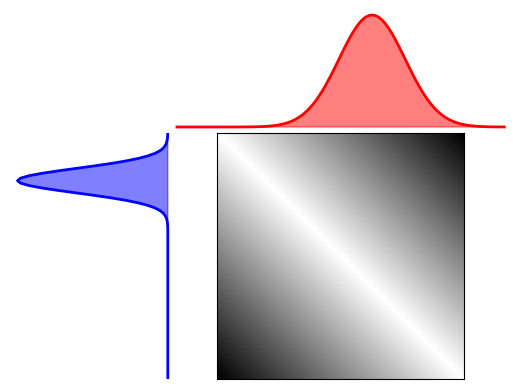

In [10]:
n = 100  # nb bins

# define bin positions
xa,a = gauss_1D(n, 20, 5)
xb,b = gauss_1D(n, 60, 10)

# Gaussian distributions
a = a/np.sum(a)
b = b/np.sum(b)

# Compute the cost matrix
C = np.abs(xa[:, None] - xb[None, :])
C = C / np.max(C) 

# Plot the cost matrix with the distributions
plot_1D(C,a,b)

Nb Iters = 3


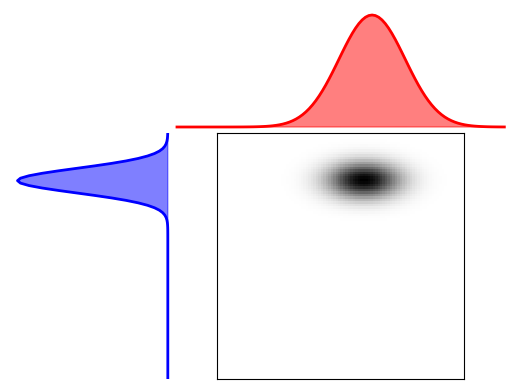

In [11]:
# Use Sinkhorn
P = sinkhorn(a, b, C, 1)

# Plot the optimal coupling with the distributions
plot_1D(P,a,b)

## 1.3. Test on 2D distributions

In [12]:
def gauss_2D(n, m, sigma):
    """Return `n` samples drawn from 2D gaussian :math:`\mathcal{N}(m, \sigma)`
    Parameters
    ----------
    n : int
        number of samples to make
    m : ndarray, shape (2,)
        mean value of the gaussian distribution
    sigma : ndarray, shape (2, 2)
        covariance matrix of the gaussian distribution
    Returns
    -------
    X : ndarray, shape (`n`, 2)
        n samples drawn from :math:`\mathcal{N}(m, \sigma)`.
    """
    P = linalg.sqrtm(sigma)
    res = np.random.randn(n, 2).dot(P) + m
    return res

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ferna\AppData\Local\Temp\ipykernel_11512\3916758156.py:2: SyntaxWarning: invalid escape sequence '\m'
  """Return `n` samples drawn from 2D gaussian :math:`\mathcal{N}(m, \sigma)`


Nb Iters = 894


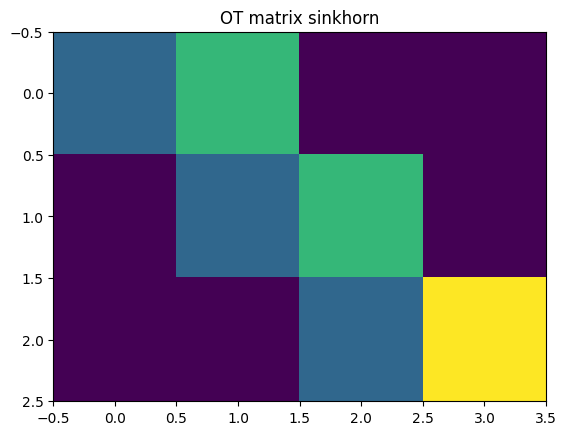

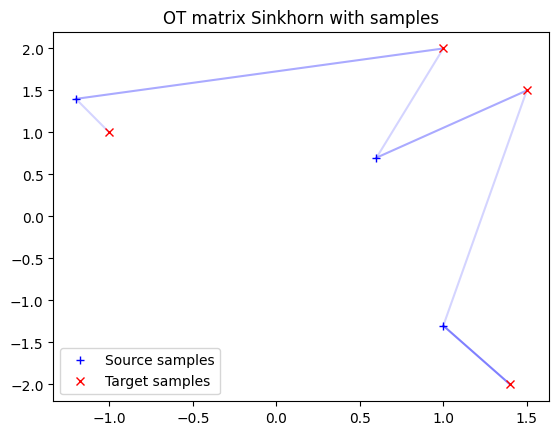

In [13]:
# Example seen in class
y1 = np.array([[-1,1],[1,2],[1.5,1.5],[1.4,-2]])
b1 = np.array([0.1,0.3,0.3,0.3])
x1 = np.array([[-1.2,1.4],[0.6,0.7],[1,-1.3]])
a1 = np.array([0.3,0.3,0.4])


# Compute the cost matrix
C1 = np.linalg.norm(x1[:, None, :] - y1[None, :, :], axis=2)
C1 = C1 / np.max(C1) 

# Use Sinkhorn with reg = 1e-3
P1 = sinkhorn(a1, b1, C1, 1e-3)

# Plot the optimal coupling with the distributions
plot_2D(x1,y1,P1)

Nb Iters = 3


C:\Users\ferna\AppData\Local\Temp\ipykernel_11512\1626960887.py:8: RuntimeWarning: overflow encountered in divide
  u = a / (K @ v)
C:\Users\ferna\AppData\Local\Temp\ipykernel_11512\1626960887.py:9: RuntimeWarning: invalid value encountered in matmul
  v = b / (K.T @ u)
C:\Users\ferna\AppData\Local\Temp\ipykernel_11512\1626960887.py:10: RuntimeWarning: invalid value encountered in matmul
  P = np.diag(u) @ K @ np.diag(v)


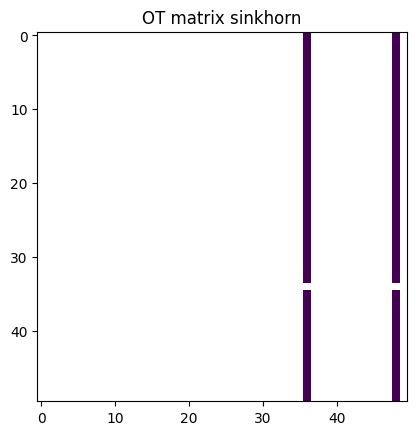

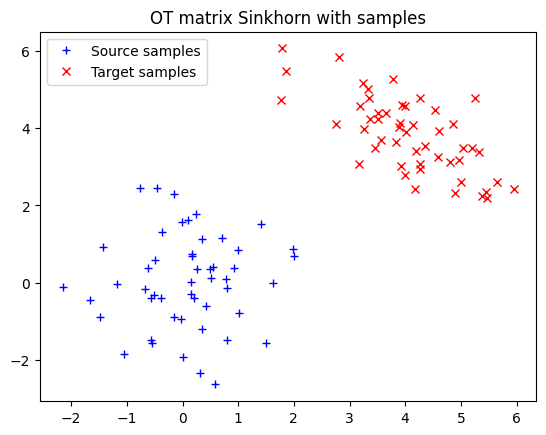

In [14]:
# Two Gaussian distributions:

n = 50  # nb bins

# Samples from a gaussian distributions
x2 = gauss_2D(n, (0,0), ((1,0),(0,1)))
y2 = gauss_2D(n, (4,4), ((1,-0.8),(-0.8,1)))

# Uniformily distributed
a2 = np.ones(n, dtype=np.float64)/n
b2 = a2

# Compute the cost matrix
C2 = np.linalg.norm(x2[:, None, :] - y2[None, :, :], axis=2)
C2 = C2 / np.max(C2) 

# Use Sinkhorn with reg = 1e-3
P2 = sinkhorn(a2, b2, C2, 1e-3)

# Plot the results
plot_2D(x2,y2,P2)

Using such a small value for the regularization (named epsilon in the CM) cause numerical instability, so I increased it to 0.5 to better represent the results.

Nb Iters = 9


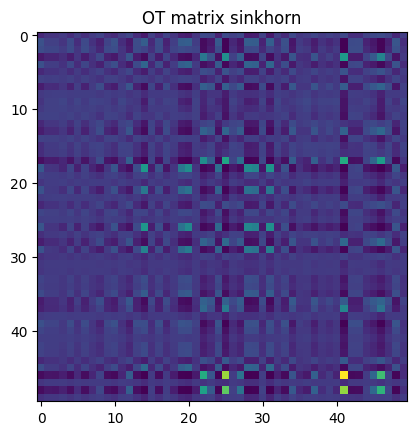

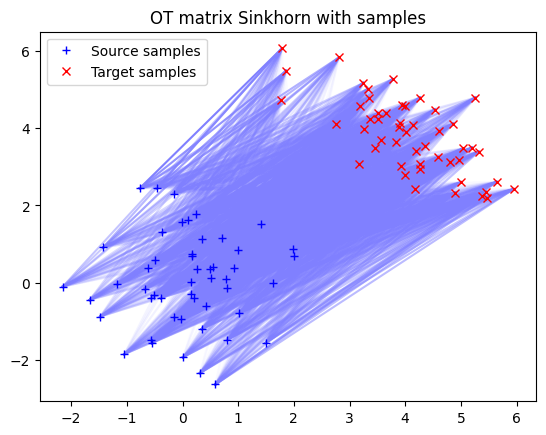

In [15]:
# Use Sinkhorn with reg = 1e-3
P2 = sinkhorn(a2, b2, C2, 0.05)

# Plot the results
plot_2D(x2,y2,P2)

Nb Iters = 11


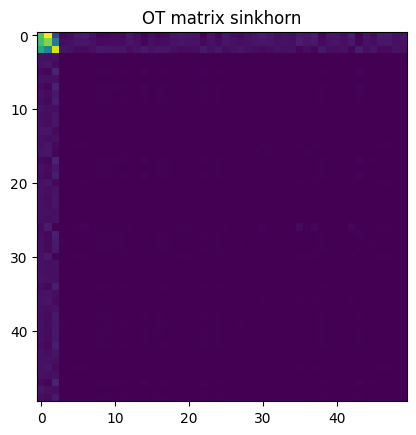

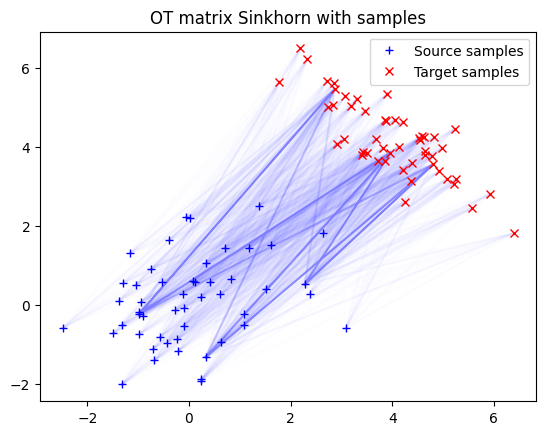

In [26]:
# Repeat the previous but now "b" has changed
b2[0:3] = 0.3

# Compute the cost matrix
C2 = np.linalg.norm(x2[:, None, :] - y2[None, :, :], axis=2)
C2 = C2 / np.max(C2) 

# Use Sinkhorn with reg = 1e-3
P2 = sinkhorn(a2, b2, C2, 0.05) 

# Plot the results
plot_2D(x2,y2,P2)

# 2. Wasserstein distance on 1D distributions

In [17]:
# Given the values x and y
x3 = np.array([0.1,2,4,0.3])
y3 = np.array([1,2,0.1,0.8])

## 2.2. Uniformily distributed 1D distributions

In [18]:
# Compute the Wasserstein distance
# Sort the samples
x3_sorted = np.sort(x3)
y3_sorted = np.sort(y3)

# Wasserstein distance for uniform case
W_uniform = np.mean(np.abs(x3_sorted - y3_sorted))
print(f"Wasserstein distance (uniform case): {W_uniform:.4f}")

Wasserstein distance (uniform case): 0.8750


## 2.3. General case 1D distributions

In [19]:
m = y3.shape[0]
# given the masses
a3 = np.array([0.1,0.4,0.2,0.3])
b3 = np.full(y3.shape, 1.0 / m, dtype=type(y3))

# Compute the Wasserstein distance the general case
# Use the helper function quantile_function

# Sort values and reorder weights accordingly
idx_a = np.argsort(x3)
idx_b = np.argsort(y3)
x3_sorted = x3[idx_a]
y3_sorted = y3[idx_b]
a3_sorted = a3[idx_a]
b3_sorted = b3[idx_b]

# Compute cumulative sums (CDFs)
Ca = np.cumsum(a3_sorted)
Cb = np.cumsum(b3_sorted)

# Define t
t = np.sort(np.concatenate((Ca,Cb)))
t = np.linspace(0, 1, 1000)

# Quantile functions
Qa = quantile_function(t, Ca, x3_sorted)
Qb = quantile_function(t, Cb, y3_sorted)

# Wasserstein distance for general case
W_general = np.mean(np.abs(Qa - Qb))
print(f"Wasserstein distance (general case): {W_general:.4f}")

Wasserstein distance (general case): 0.8750


# 3. Comparison with the POT library

In [20]:
!pip install pot

#### 1.1. Implement the Sinkhorn-Knopp algorithm

In [21]:
import ot

a=np.array([.5, .5])
b=np.array([.5, .5])
M=np.array([[0., 1.], [1., 0.]])
sinkhorn(a, b, M, 1)
P = ot.sinkhorn(a, b, M, 1)
print(P)

Nb Iters = 1
[[0.36552929 0.13447071]
 [0.13447071 0.36552929]]


#### 1.2 Test on 1D Distribuitions 

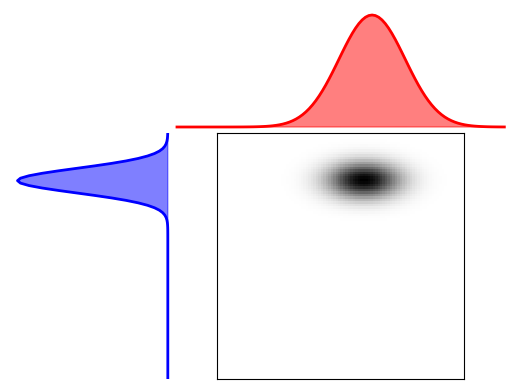

In [22]:
n = 100  # nb bins

# define bin positions
xa,a = gauss_1D(n, 20, 5)
xb,b = gauss_1D(n, 60, 10)

# Gaussian distributions
a = a/np.sum(a)
b = b/np.sum(b)

# Compute the cost matrix
C = np.abs(xa[:, None] - xb[None, :])
C = C / np.max(C) 

# Use Sinkhorn
P = ot.sinkhorn(a, b, C, 1)

# Plot the optimal coupling with the distributions
plot_1D(P,a,b)

#### 1.3. Test on 2D distributions

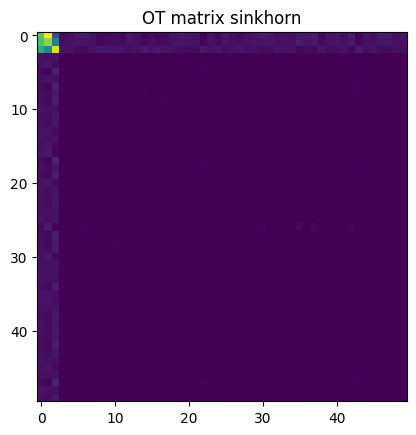

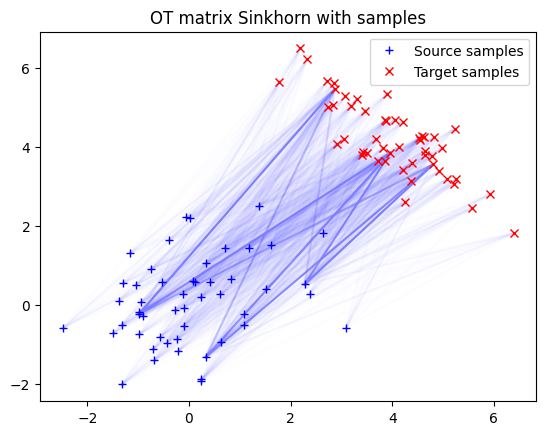

In [28]:
# Compute the cost matrix
C2 = ot.dist(x2, y2, metric='euclidean')

# Use Sinkhorn with reg = 1e-3
P2 = ot.sinkhorn(a2, b2, C2, 0.5)

# Plot the results
plot_2D(x2,y2,P2)

#### 2.2. Uniformily distributed 1D distributions

In [ ]:
n = len(x3)
a_uniform = np.full(n, 1/n)
b_uniform = np.full(n, 1/n)

# Cost matrix for 1D: |x - y|
C3 = ot.dist(x3_sorted[:, None], y3_sorted[:, None], metric='euclidean')

# Compute OT (emd2 gives squared cost)
W2_uniform = ot.emd2(a_uniform, b_uniform, C3)
W_uniform_pot = np.sqrt(W2_uniform)

print(f"Wasserstein distance (uniform, POT): {W_uniform:.4f}")

Wasserstein distance (uniform, POT): 0.8750


#### 2.3. General case 1D distributions

In [ ]:
# Cost matrix for 1D
C_general = ot.dist(x3_sorted[:, None], y3_sorted[:, None], metric='euclidean')

# Compute OT cost
W2_general = ot.emd2(a3_sorted, b3_sorted, C_general)
W_general_pot = np.sqrt(W2_general)

print(f"Wasserstein distance (general case, POT): {W_general:.4f}")


Wasserstein distance (general case, POT): 0.8750


# 4. Applications
